In [1]:
!pip install -q datasets huggingface_hub pyarrow pandas numpy


In [3]:
import pandas as pd
import numpy as np
from huggingface_hub import hf_hub_download
from datasets import load_dataset

REPO_GOLD = "chuongdo1104/amazon-2023-gold"
REPO_SILVER = "chuongdo1104/amazon-2023-silver"

# 1. Tải ID Maps (Gold maps là file đơn được lưu bằng PyArrow)
print("Đang tải ID Mappings...")
item_map_path = hf_hub_download(repo_id=REPO_GOLD, filename="gold/gold_item_id_map.parquet", repo_type="dataset")
user_map_path = hf_hub_download(repo_id=REPO_GOLD, filename="gold/gold_user_id_map.parquet", repo_type="dataset")
df_item_map = pd.read_parquet(item_map_path)
df_user_map = pd.read_parquet(user_map_path)

# Tạo từ điển tra cứu nhanh (Dictionary Lookup)
item2idx = dict(zip(df_item_map['parent_asin'], df_item_map['item_idx']))
user2idx = dict(zip(df_user_map['reviewer_id'], df_user_map['user_idx']))

# 2. Tải Edge Index (Ma trận kề PyG)
print("Đang tải Graph Edge Index...")
edge_index_path = hf_hub_download(repo_id=REPO_GOLD, filename="gold/gold_edge_index.npy", repo_type="dataset")
edges = np.load(edge_index_path)
edge_set = set(zip(edges[0], edges[1]))

# 3. Tải Validation Ground Truth (THAY ĐỔI Ở ĐÂY: Dùng load_dataset thay vì hf_hub_download)
print("Đang tải Validation Ground Truth...")
ds_val_gt = load_dataset(REPO_SILVER, data_dir="silver/silver_val_ground_truth.parquet", split="train")
df_val_gt = ds_val_gt.to_pandas()

# 4. Tải 100 sample từ Train Set (Dùng datasets để stream nhanh 1 part)
print("Đang tải mẫu Train Interactions...")
ds_train = load_dataset(REPO_SILVER, data_dir="silver/silver_interactions_train.parquet", split="train", streaming=True)
df_train_sample = pd.DataFrame(list(ds_train.take(100)))

print("\n✅ Tải dữ liệu hoàn tất!")


Đang tải ID Mappings...
Đang tải Graph Edge Index...
Đang tải Validation Ground Truth...


silver/silver_val_ground_truth.parquet/p(…):   0%|          | 0.00/13.3M [00:00<?, ?B/s]

silver/silver_val_ground_truth.parquet/p(…):   0%|          | 0.00/8.53M [00:00<?, ?B/s]

silver/silver_val_ground_truth.parquet/p(…):   0%|          | 0.00/13.4M [00:00<?, ?B/s]

silver/silver_val_ground_truth.parquet/p(…):   0%|          | 0.00/6.47M [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Đang tải mẫu Train Interactions...

✅ Tải dữ liệu hoàn tất!


In [4]:
print("="*60)
print(" KIỂM TRA 1: TÍNH TOÀN VẸN CỦA ID MAPPING")
print("="*60)
print(f"Tổng số User Map: {len(user2idx):,}")
print(f"Tổng số Item Map: {len(item2idx):,}")

max_user_idx = df_user_map['user_idx'].max()
max_item_idx = df_item_map['item_idx'].max()

print(f"\nMax User Index: {max_user_idx} (Kỳ vọng phải là: {len(user2idx)-1})")
if max_user_idx != len(user2idx)-1: print("❌ LỖI: Index của User bị đứt gãy không liên tục!")

print(f"Max Item Index: {max_item_idx} (Kỳ vọng phải là: {len(item2idx)-1})")
if max_item_idx != len(item2idx)-1: print("❌ LỖI: Index của Item bị đứt gãy không liên tục!")


 KIỂM TRA 1: TÍNH TOÀN VẸN CỦA ID MAPPING
Tổng số User Map: 1,483,920
Tổng số Item Map: 1,610,012

Max User Index: 1483919 (Kỳ vọng phải là: 1483919)
Max Item Index: 1610011 (Kỳ vọng phải là: 1610011)


In [5]:
print("="*60)
print(" KIỂM TRA 2: MISSING ID TRONG TẬP ĐÁNH GIÁ (VAL SET)")
print("="*60)
val_users = df_val_gt['reviewer_id'].unique()
val_items = df_val_gt['parent_asin'].unique()

missing_users = [u for u in val_users if u not in user2idx]
missing_items = [i for i in val_items if i not in item2idx]

print(f"Số lượng Users duy nhất trong Val: {len(val_users):,}")
print(f"  -> Không có mặt trong ID Map: {len(missing_users)} users ({(len(missing_users)/len(val_users))*100:.4f}%)")

print(f"\nSố lượng Items duy nhất trong Val: {len(val_items):,}")
print(f"  -> Không có mặt trong ID Map: {len(missing_items)} items ({(len(missing_items)/len(val_items))*100:.4f}%)")

if len(missing_items) > 0 or len(missing_users) > 0:
    print("\n❌ CẢNH BÁO NGUY HIỂM: Tập ID Map không cover hết tập Đánh Giá. Đây là nguyên nhân trực tiếp làm hàm Evaluate báo lỗi hoặc trả về 0 vì không lookup được Embedding ID!")
else:
    print("\n✅ Tốt! Toàn bộ User và Item trong tập Val đều đã có mặt trong không gian Index.")


 KIỂM TRA 2: MISSING ID TRONG TẬP ĐÁNH GIÁ (VAL SET)
Số lượng Users duy nhất trong Val: 1,483,920
  -> Không có mặt trong ID Map: 0 users (0.0000%)

Số lượng Items duy nhất trong Val: 343,699
  -> Không có mặt trong ID Map: 0 items (0.0000%)

✅ Tốt! Toàn bộ User và Item trong tập Val đều đã có mặt trong không gian Index.


In [6]:
print("="*60)
print(" KIỂM TRA 3: ĐỒNG BỘ EDGE INDEX VÀ TEXT INTERACTIONS")
print("="*60)

matched = 0
# Lấy 5 mẫu ngẫu nhiên đầu tiên
for idx, row in df_train_sample.head(5).iterrows():
    uid = row['reviewer_id']
    iid = row['parent_asin']
    u_idx = user2idx.get(uid, -1)
    i_idx = item2idx.get(iid, -1)

    is_in_graph = (u_idx, i_idx) in edge_set
    if is_in_graph: matched += 1

    print(f"🔹 Train Sample {idx}: User '{uid[:10]}...' mua Item '{iid}'")
    print(f"  -> Map ra Integer ID: (User_idx: {u_idx}, Item_idx: {i_idx})")
    print(f"  -> Cặp ID này có tồn tại trong `gold_edge_index.npy` không? : {'✅ CÓ' if is_in_graph else '❌ KHÔNG'}\n")

if matched == 5:
    print("✅ KẾT LUẬN: Bảng ID Map và file Graph Edges hoàn toàn đồng bộ với nhau!")
else:
    print("❌ CẢNH BÁO: Bảng ID Map và Graph bị lệch pha (Mismatch). Đồ thị đã bị xáo trộn ID!")


 KIỂM TRA 3: ĐỒNG BỘ EDGE INDEX VÀ TEXT INTERACTIONS
🔹 Train Sample 0: User 'AE22236AFR...' mua Item 'B000XT3L7W'
  -> Map ra Integer ID: (User_idx: 0, Item_idx: 75372)
  -> Cặp ID này có tồn tại trong `gold_edge_index.npy` không? : ✅ CÓ

🔹 Train Sample 1: User 'AE22236AFR...' mua Item 'B001U5PKJ0'
  -> Map ra Integer ID: (User_idx: 0, Item_idx: 109793)
  -> Cặp ID này có tồn tại trong `gold_edge_index.npy` không? : ✅ CÓ

🔹 Train Sample 2: User 'AE2227QSJS...' mua Item 'B08THX4N12'
  -> Map ra Integer ID: (User_idx: 1, Item_idx: 1335898)
  -> Cặp ID này có tồn tại trong `gold_edge_index.npy` không? : ✅ CÓ

🔹 Train Sample 3: User 'AE222ZJTJP...' mua Item 'B0C4TZT4Y9'
  -> Map ra Integer ID: (User_idx: 7, Item_idx: 1597005)
  -> Cặp ID này có tồn tại trong `gold_edge_index.npy` không? : ✅ CÓ

🔹 Train Sample 4: User 'AE2232IXUS...' mua Item 'B001FB6SI6'
  -> Map ra Integer ID: (User_idx: 9, Item_idx: 96475)
  -> Cặp ID này có tồn tại trong `gold_edge_index.npy` không? : ✅ CÓ

✅ KẾT LUẬN: 

In [7]:
print("="*60)
print(" KIỂM TRA 4: MÔ PHỎNG LUỒNG EVALUATION & KIỂM TRA LEAKAGE")
print("="*60)

sample_val = df_val_gt.iloc[0]
val_uid = sample_val['reviewer_id']
val_iid = sample_val['parent_asin']
val_uidx = user2idx.get(val_uid, -1)
val_iidx = item2idx.get(val_iid, -1)

print(f"Lấy 1 tương tác Ground Truth ngẫu nhiên từ Validation:")
print(f"  • Raw ID : User '{val_uid}' → Target Item '{val_iid}'")
print(f"  • Cần dò  : Vector Embedding của User_idx [{val_uidx}] và Item_idx [{val_iidx}]")

print("\nKiểm tra độ cách ly (Cô lập dữ liệu đánh giá):")
is_leak = (val_uidx, val_iidx) in edge_set
if is_leak:
    print(f"  -> ❌ BỊ RÒ RỈ (Data Leakage): Cặp Test này LẠI CÓ MẶT trong Graph Train (gold_edge_index.npy)!")
else:
    print(f"  -> ✅ Tốt! Cặp này không hề xuất hiện trong Graph huấn luyện.")

print("\n" + "="*60)
print("💡 HƯỚNG DẪN ĐIỀU TRA TIẾP THEO TRONG XDMH.ipynb:")
print(f"Nếu 4 bài test trên đều Pass (Xanh), thì Lỗi Mapping Nằm Ở KHÂU LLM EMBEDDING!")
print(f"Hãy viết code vào XDMH.ipynb để print: `print(item_embeddings_tensor.shape[0])`")
print(f"Nếu `.shape[0]` của Tensor Nhúng Ngôn Ngữ không bằng đúng {len(item2idx)}, toàn bộ ma trận chấm điểm sẽ nhân sai hàng/cột, dẫn tới Recall vĩnh viễn bằng 0.")


 KIỂM TRA 4: MÔ PHỎNG LUỒNG EVALUATION & KIỂM TRA LEAKAGE
Lấy 1 tương tác Ground Truth ngẫu nhiên từ Validation:
  • Raw ID : User 'AE222KSFP7UXSULU6I34OU2A2DUQ' → Target Item 'B01AT23UGE'
  • Cần dò  : Vector Embedding của User_idx [4] và Item_idx [626610]

Kiểm tra độ cách ly (Cô lập dữ liệu đánh giá):
  -> ✅ Tốt! Cặp này không hề xuất hiện trong Graph huấn luyện.

💡 HƯỚNG DẪN ĐIỀU TRA TIẾP THEO TRONG XDMH.ipynb:
Nếu 4 bài test trên đều Pass (Xanh), thì Lỗi Mapping Nằm Ở KHÂU LLM EMBEDDING!
Hãy viết code vào XDMH.ipynb để print: `print(item_embeddings_tensor.shape[0])`
Nếu `.shape[0]` của Tensor Nhúng Ngôn Ngữ không bằng đúng 1610012, toàn bộ ma trận chấm điểm sẽ nhân sai hàng/cột, dẫn tới Recall vĩnh viễn bằng 0.


In [8]:
import numpy as np
from huggingface_hub import hf_hub_download

REPO_GOLD = "chuongdo1104/amazon-2023-gold"

# Danh sách các file .npy cần đọc
npy_files = [
    "gold/gold_item_train_freq.npy",
    "gold/gold_user_train_freq.npy",
    "gold/gold_item_popularity_group.npy",
    "gold/gold_user_activity_group.npy",
    "gold/gold_negative_sampling_prob.npy"
]

print("="*60)
print(" KIỂM TRA CÁC MẢNG NUMPY (.npy) TẦNG GOLD")
print("="*60)

for file_name in npy_files:
    print(f"\nĐang tải và đọc: {file_name}...")

    # Tải file về local cache của Colab
    file_path = hf_hub_download(repo_id=REPO_GOLD, filename=file_name, repo_type="dataset")

    # Load vào RAM bằng numpy
    arr = np.load(file_path)

    # In thống kê chung
    print(f"  • Kích thước (Shape) : {arr.shape}")
    print(f"  • Kiểu dữ liệu (Dtype): {arr.dtype}")
    print(f"  • 5 giá trị đầu tiên : {arr[:5]}")

    # Một chút thống kê vui nếu là mảng số thực/số nguyên
    if np.issubdtype(arr.dtype, np.number):
        print(f"  • Min = {arr.min()}, Max = {arr.max()}, Mean = {arr.mean():.4f}")


 KIỂM TRA CÁC MẢNG NUMPY (.npy) TẦNG GOLD

Đang tải và đọc: gold/gold_item_train_freq.npy...


gold/gold_item_train_freq.npy:   0%|          | 0.00/12.9M [00:00<?, ?B/s]

  • Kích thước (Shape) : (1610012,)
  • Kiểu dữ liệu (Dtype): int64
  • 5 giá trị đầu tiên : [0 0 0 0 0]
  • Min = 0, Max = 33737, Mean = 6.9089

Đang tải và đọc: gold/gold_user_train_freq.npy...


gold/gold_user_train_freq.npy:   0%|          | 0.00/11.9M [00:00<?, ?B/s]

  • Kích thước (Shape) : (1483920,)
  • Kiểu dữ liệu (Dtype): int64
  • 5 giá trị đầu tiên : [18  4 14  4  3]
  • Min = 3, Max = 938, Mean = 7.4960

Đang tải và đọc: gold/gold_item_popularity_group.npy...


...

  • Kích thước (Shape) : (1610012,)
  • Kiểu dữ liệu (Dtype): int8
  • 5 giá trị đầu tiên : [3 3 3 3 3]
  • Min = 0, Max = 3, Mean = 2.1337

Đang tải và đọc: gold/gold_user_activity_group.npy...


gold/gold_user_activity_group.npy:   0%|          | 0.00/1.48M [00:00<?, ?B/s]

  • Kích thước (Shape) : (1483920,)
  • Kiểu dữ liệu (Dtype): int8
  • 5 giá trị đầu tiên : [1 0 1 0 0]
  • Min = 0, Max = 2, Mean = 0.5982

Đang tải và đọc: gold/gold_negative_sampling_prob.npy...


gold/gold_negative_sampling_prob.npy:   0%|          | 0.00/6.44M [00:00<?, ?B/s]

  • Kích thước (Shape) : (1610012,)
  • Kiểu dữ liệu (Dtype): float32
  • 5 giá trị đầu tiên : [2.0538943e-07 2.0538943e-07 2.0538943e-07 2.0538943e-07 2.0538943e-07]
  • Min = 2.053894263553957e-07, Max = 0.0005112789804115891, Mean = 0.0000


Kiểm tra test trên Bronze

Đang tải tập Bronze Test từ Hugging Face...
📦 THỐNG KÊ TẬP BRONZE TEST
Tổng số tương tác (Interactions): 1,483,920
Tổng số User độc nhất: 1,483,920
Tổng số Item độc nhất: 332,677

Hiển thị 5 dòng đầu tiên:


,parent_asin,rating,review_title,review_text,timestamp,helpful_vote,reviewer_id
0,B09DGDTF32,5.0,Excellent product.,The watch was just as described. Not any compl...,1651393068,1,AE222T2BWBACWZJFX62EIFSY67YA
1,B08H5GD51Y,5.0,Perfect,Easy to install and modify my setup. I am usin...,1631475084,0,AE223CYZV5SRNYU7XMWMS7UIK36Q
2,B07H8PKR21,5.0,Very well built.,This monitor stand is very well built and easy...,1643979731,0,AE224EFKNL3XBZDNWNYDVRMJKG2Q
3,B09PTNYQ3K,5.0,Good product,Good product ..,1665930573,0,AE224GVO7OHTYF26U6ER6BEVIUAQ
4,B003GXFNYQ,5.0,Five Stars,Excelente,1423763100,0,AE225JBALF4TIEBHVLZRWSU2IJJQ


/tmp/ipykernel_10099/245945373.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_test, x='year', palette='viridis')


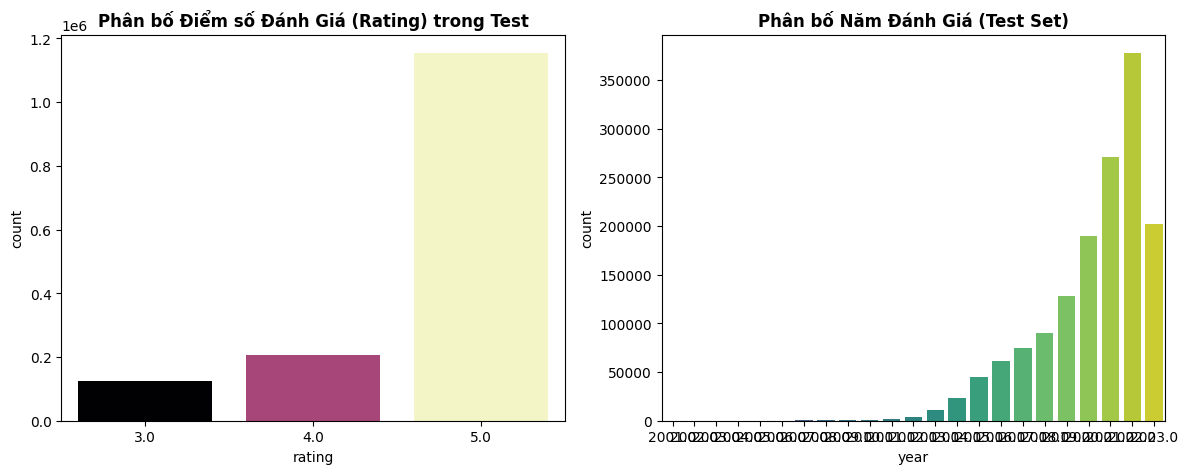

🔍 KIỂM TRA ĐỒNG BỘ VỚI TẬP GOLD (ID MAPPINGS)
Kiểm tra 1,483,920 Users của Test Set:
  ✅ Hoàn hảo! 100% User đều có ID hợp lệ để đánh giá.

Kiểm tra 332,677 Items của Test Set:
  ✅ Hoàn hảo! 100% Item đều có ID hợp lệ để đánh giá.


In [10]:
from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

REPO_BRONZE = "chuongdo1104/amazon-2023-bronze"

print("Đang tải tập Bronze Test từ Hugging Face...")
# Hugging Face coi các file bên trong thư mục parquet là "train" split mặc định
ds_test = load_dataset(REPO_BRONZE, data_dir="bronze/bronze_test.parquet", split="train")
df_test = ds_test.to_pandas()

print("="*60)
print(f"📦 THỐNG KÊ TẬP BRONZE TEST")
print("="*60)
print(f"Tổng số tương tác (Interactions): {len(df_test):,}")
print(f"Tổng số User độc nhất: {df_test['reviewer_id'].nunique():,}")
print(f"Tổng số Item độc nhất: {df_test['parent_asin'].nunique():,}")
print("\nHiển thị 5 dòng đầu tiên:")
display(df_test.head())

# 1. Biểu đồ phân bổ đánh giá (Rating)
# Đáng lẽ toàn bộ phải >= 3.0 (vì Core-5 đã filter từ Bronze)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.countplot(data=df_test, x='rating', palette='magma', hue='rating', legend=False)

plt.title('Phân bố Điểm số Đánh Giá (Rating) trong Test', fontweight='bold')

# 2. Biểu đồ phân bố thời gian
# Xem các tương tác cuối cùng của users rải rác ở những năm nào
df_test['datetime'] = pd.to_datetime(df_test['timestamp'], unit='s', errors='coerce')

df_test['year'] = df_test['datetime'].dt.year

plt.subplot(1, 2, 2)
sns.countplot(data=df_test, x='year', palette='viridis')

plt.title('Phân bố Năm Đánh Giá (Test Set)', fontweight='bold')
plt.tight_layout()
plt.show()

# 3. KIỂM TRA CHÉO (CROSS-CHECK) CHỐNG RÒ RỈ VÀ LỖI MAPPING
# (Yêu cầu phải chạy các Cell chứa user2idx và item2idx trước)
print("="*60)
print("🔍 KIỂM TRA ĐỒNG BỘ VỚI TẬP GOLD (ID MAPPINGS)")
print("="*60)

test_users = df_test['reviewer_id'].unique()
test_items = df_test['parent_asin'].unique()

missing_test_users = [u for u in test_users if u not in user2idx]
missing_test_items = [i for i in test_items if i not in item2idx]

print(f"Kiểm tra {len(test_users):,} Users của Test Set:")
if len(missing_test_users) > 0:
    print(f"  ❌ CẢNH BÁO: Có {len(missing_test_users):,} Users KHÔNG CÓ trong ID Map!")
else:
    print(f"  ✅ Hoàn hảo! 100% User đều có ID hợp lệ để đánh giá.")

print(f"\nKiểm tra {len(test_items):,} Items của Test Set:")
if len(missing_test_items) > 0:
    print(f"  ❌ CẢNH BÁO: Có {len(missing_test_items):,} Items KHÔNG CÓ trong ID Map!")
    # In ra thử 5 item bị lỗi
    print(f"      (Ví dụ: {missing_test_items[:5]})")
    print("\n⚠️ Nếu Items bị hụt, đây CHÍNH LÀ nguyên nhân gây ra kết quả Recall/NDCG = 0.0!")
else:
    print(f"  ✅ Hoàn hảo! 100% Item đều có ID hợp lệ để đánh giá.")


In [11]:
import random
import numpy as np
from tqdm.auto import tqdm

print("="*60)
print(" TIỀN XỬ LÝ TẬP ĐÁNH GIÁ (1 POSITIVE + 100 NEGATIVES)")
print("="*60)

# 1. Trích xuất Lịch sử Huấn luyện (Train History) từ Graph Edges
print("1. Xây dựng Hash Map lịch sử tương tác Train để mask (loại trừ)...")
train_history = {}
# edges[0] là danh sách user_idx, edges[1] là danh sách item_idx
for u, i in zip(edges[0], edges[1]):
    if u not in train_history:
        train_history[u] = set()
    train_history[u].add(i)

num_items = len(item2idx)
num_negatives = 100

# Để demo hoặc đánh giá nhanh mỗi epoch, ta lấy mẫu 10,000 Users (full 1.4M users mất ~5-10p)
# Bạn có thể bỏ .sample() nếu muốn evaluate full tập test
df_eval = df_test.sample(10000, random_state=42)
eval_data = []

print("2. Đang sinh 100 Negatives cho mỗi User...")
# Cố định random seed để evaluation ổn định
random.seed(42)

for _, row in tqdm(df_eval.iterrows(), total=len(df_eval)):
    u_idx = user2idx[row['reviewer_id']]
    pos_item_idx = item2idx[row['parent_asin']]

    # Dò lại lịch sử train của user
    u_history = train_history.get(u_idx, set())

    neg_items = set()
    while len(neg_items) < num_negatives:
        neg_item = random.randint(0, num_items - 1)
        # Nguyên tắc cốt lõi: Không trùng Positive, Không trùng Train History
        if neg_item != pos_item_idx and neg_item not in u_history:
            neg_items.add(neg_item)

    # Gom lại thành Record
    eval_data.append({
        'user_idx': u_idx,
        'pos_item_idx': pos_item_idx,
        'neg_item_idxs': list(neg_items)
    })

print(f"\n✅ Đã tiền xử lý xong {len(eval_data):,} mẫu đánh giá!")

# Xem thử 1 mẫu
sample_record = eval_data[0]
print("\n[VÍ DỤ MẪU EVALUATION]:")
print(f" - User Index : {sample_record['user_idx']}")
print(f" - Mồi chuẩn (Positive) : {sample_record['pos_item_idx']}")
print(f" - 100 Hàng Nhái (Negatives) : {sample_record['neg_item_idxs'][:5]} ...")


 TIỀN XỬ LÝ TẬP ĐÁNH GIÁ (1 POSITIVE + 100 NEGATIVES)
1. Xây dựng Hash Map lịch sử tương tác Train để mask (loại trừ)...
2. Đang sinh 100 Negatives cho mỗi User...


  0%|          | 0/10000 [00:00<?, ?it/s]


✅ Đã tiền xử lý xong 10,000 mẫu đánh giá!

[VÍ DỤ MẪU EVALUATION]:
 - User Index : 973620
 - Mồi chuẩn (Positive) : 1547949
 - 100 Hàng Nhái (Negatives) : [1277440, 233478, 886286, 1405459, 62489] ...
